In [1]:
import arviz as az
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')

az.style.use("arviz-viridish")

## Access the possible variance

In [2]:
from mfgpflow.data_loader import SMFDataLoader

base_dir = "/Users/jibanmac/Documents/GitHub/camels_resolution/"
param_file = os.path.join(base_dir, "data/illustris_smfs/CosmoAstroSeed_params.txt")
lh_smf_file = os.path.join(base_dir, "data/illustris_smfs/LH_smf_10bins.npy")
low_smf_file = os.path.join(base_dir, "data/illustris_smfs/low_smf_10bins.npy")
high_smf_file = os.path.join(base_dir, "data/illustris_smfs/high_smf_10bins.npy")
additional_low_smf_files = [os.path.join(base_dir,"data/illustris-5-8/low_smf_10bins.npy")]
additional_high_smf_files = [os.path.join(base_dir,"data/illustris-5-8/high_smf_10bins.npy")]

# Create an instance of the SMFDataLoader class
smf_loader = SMFDataLoader(
    param_file,
    lh_smf_file,
    low_smf_file,
    high_smf_file,
    additional_low_smf_files,
    additional_high_smf_files,
)

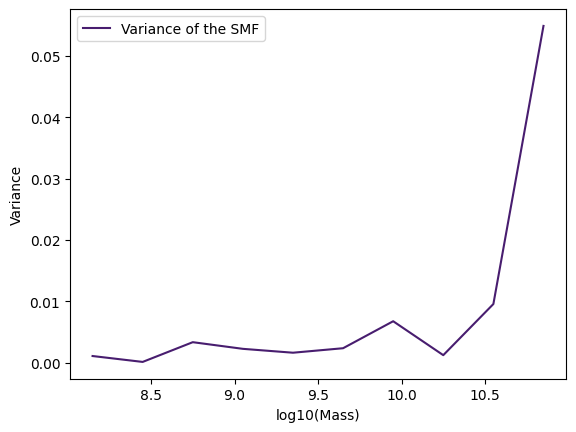

In [3]:
# calculation of variance of the SMF from different realizations
log_smf_seed1 = np.log10(smf_loader.low_smfs[smf_loader.order_optimal_index])
log_smf_seed2 = np.log10(smf_loader.lh_smfs[smf_loader.optimal_index[smf_loader.optimal_index != -1]])

# Calculate the variance of the SMF
#  \sigma_{\phi,c}^2(M) for each cosmology, compute the mean variance across all four cosmologies:
# \bar{\sigma}{\phi}^2(M) = \frac{1}{4} \sum{c=1}^{4} \sigma_{\phi,c}^2(M)
# This represents the expected variance due to both cosmic variance and stochasticity in the simulation.
variance = (10**log_smf_seed1 - 10**log_smf_seed2) ** 2 / 2.0
# Transform variance to log space
log_variance = variance * (1 / 10**log_smf_seed1 / np.log(10)) ** 2 # log10(variance) = 2 * log10(smf1 - smf2) - 2 * log10(smf1) - log10(smf2)
log_variance = np.mean(log_variance, axis=0)
# Compute the median variance across all four cosmologies
variance = np.mean(variance, axis=0)
plt.plot(smf_loader.log10_mass_bins, log_variance, label="Variance of the SMF")
plt.xlabel("log10(Mass)")
plt.ylabel("Variance")
plt.legend()
plt.show()

/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_75516/3750437374.py:130: RuntimeWarning: divide by zero encountered in divide
  (ar1_pred_means[i] - data.Y_train_log10[1][i])


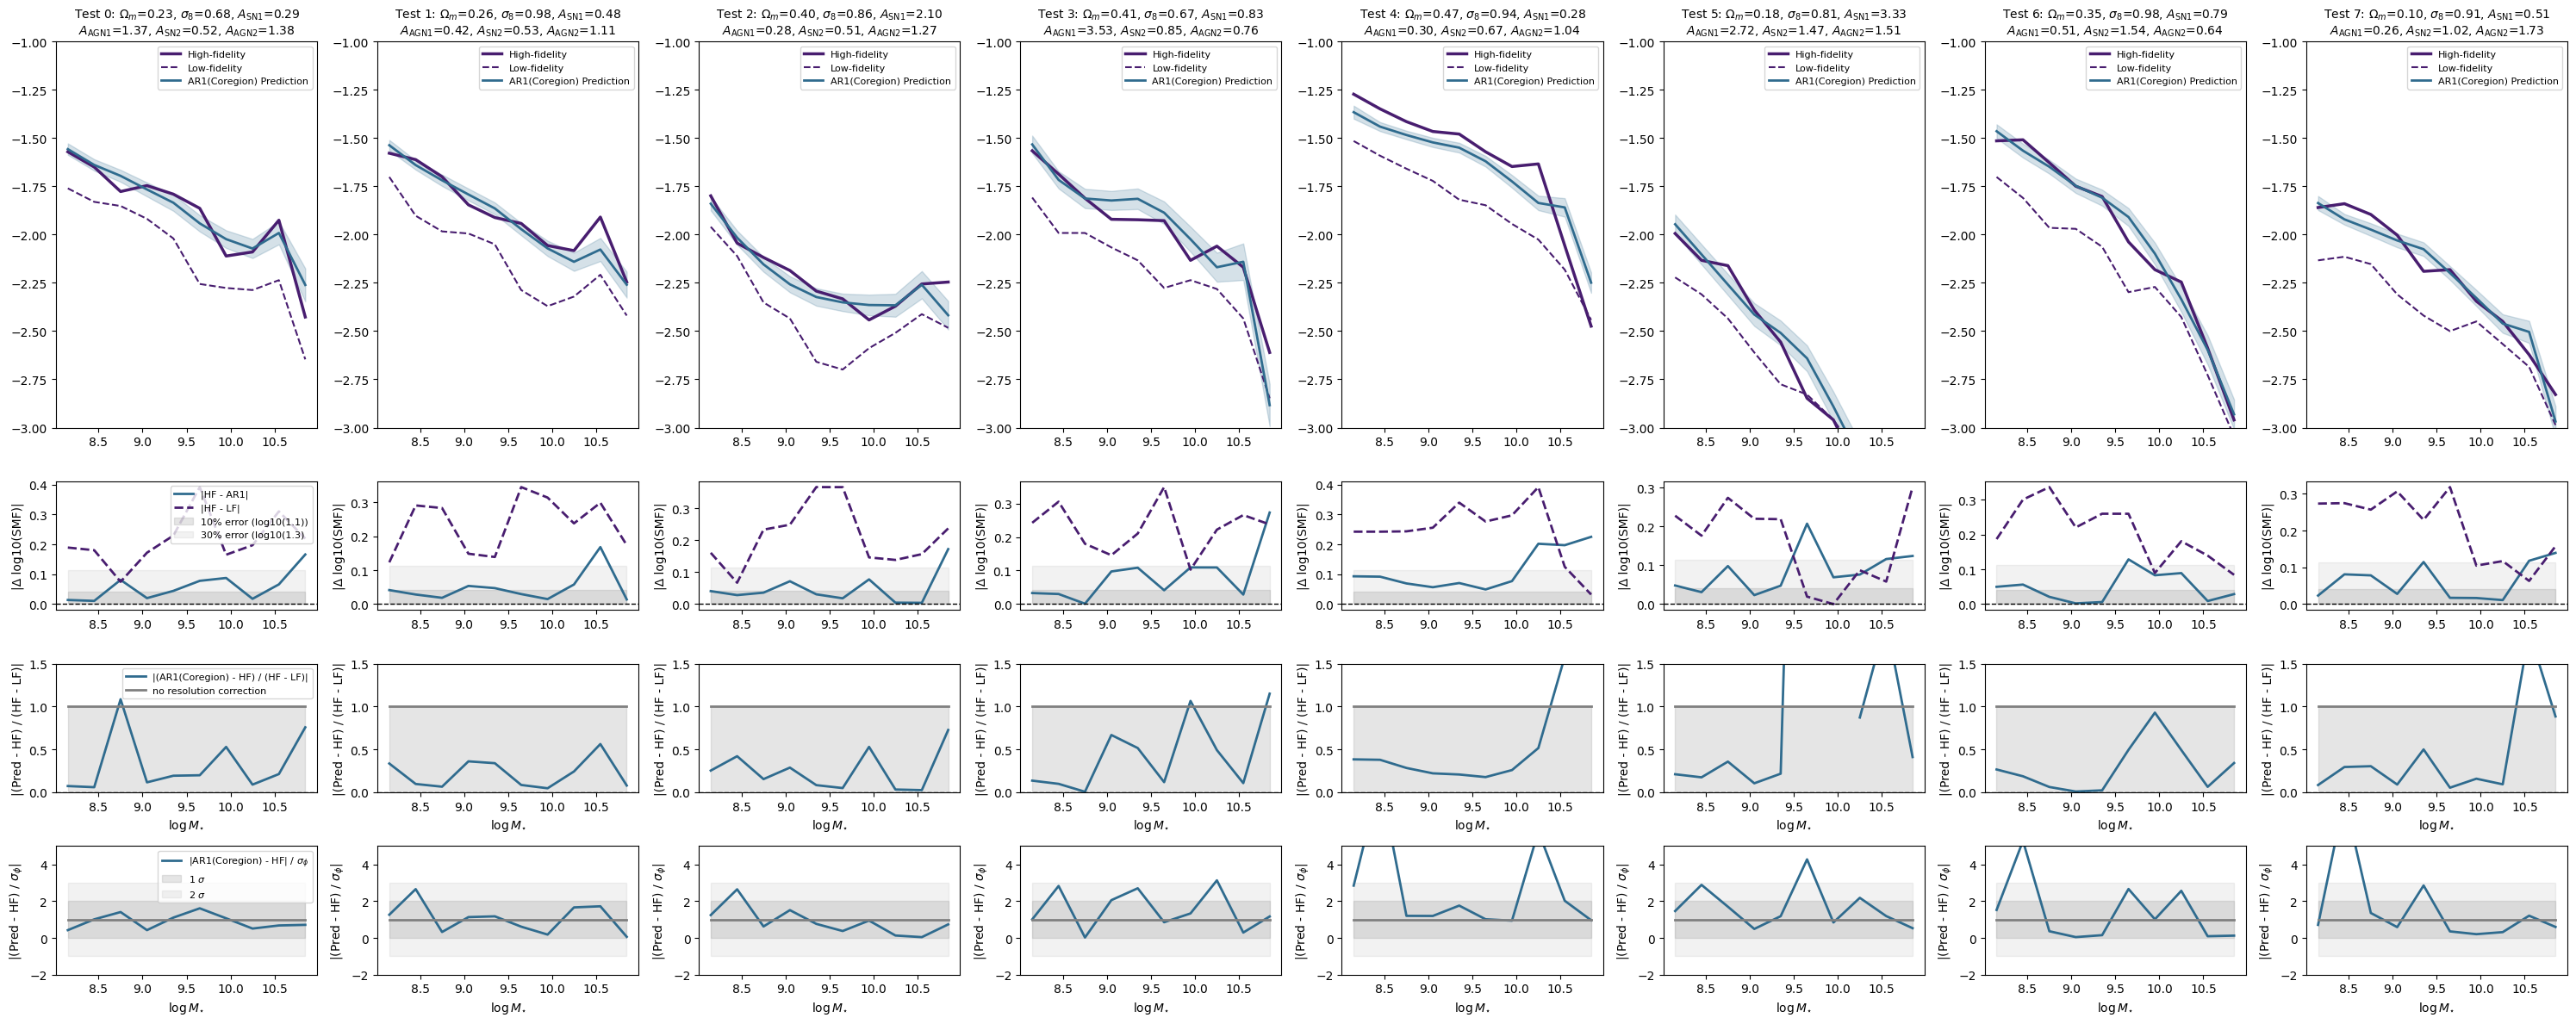

In [4]:

from mfgpflow.data_loader import StellarMassFunctions

log10_mass_bins = np.array(
            [8.15, 8.45, 8.75, 9.05, 9.35, 9.65, 9.95, 10.25, 10.55, 10.85]
        )

# Directory containing results
results_dir = "../../results_200_5"
idx = 996

# Identify LOO test folders (excluding "full_*" folders)
loo_test_folders = sorted([
    f for f in os.listdir(results_dir)
    if f.startswith("1004_LR_7_HR_test") and os.path.isdir(os.path.join(results_dir, f))
])

num_loo = len(loo_test_folders)  # Number of leave-one-out tests

def generate_data(folder: str = "../../data/illustris/illustris-5-8/1004_LR_7_HR_test0/"):
    data = StellarMassFunctions(folder=folder)
    return data

base_folder = "../../data/illustris/illustris-5-8-log1p/full_1004_LR_8_HR_test0/"
data = generate_data(base_folder)

# Storage for predictions and variances
ar1_pred_means = []
ar1_pred_vars = []

for folder in loo_test_folders:
    model_dir = os.path.join(results_dir, folder, "models")
    
    # Load predictions and variance data
    predictions = np.loadtxt(os.path.join(model_dir, "predictions.txt"))
    variances = np.loadtxt(os.path.join(model_dir, "variances.txt"))
    
    ar1_pred_means.append(predictions)
    ar1_pred_vars.append(variances)

ar1_pred_means = np.array(ar1_pred_means)
ar1_pred_vars = np.array(ar1_pred_vars)

# Plotting
fig, axs = plt.subplots(4, num_loo, figsize=(30, 12), gridspec_kw={"height_ratios": [3, 1, 1, 1]})

for i, folder in enumerate(loo_test_folders):
    ax_top = axs[0, i]
    
    # Plot high-fidelity and low-fidelity SMFs
    ax_top.plot(log10_mass_bins, data.Y_train_log10[1][i], label="High-fidelity", color="C0", lw=2.5)
    ax_top.plot(log10_mass_bins, data.Y_train_log10[0][idx + i], color="C0", ls="--", label="Low-fidelity")
    
    # Plot AR1 Predictions
    lower = ar1_pred_means[i] - np.sqrt(ar1_pred_vars[i])
    upper = ar1_pred_means[i] + np.sqrt(ar1_pred_vars[i])
    # lower[lower <= 0] = 1e-5  # Avoid log issues
    ax_top.plot(log10_mass_bins, ar1_pred_means[i], label="AR1(Coregion) Prediction", color="C1", lw=2)
    ax_top.fill_between(log10_mass_bins, lower, upper, color="C1", alpha=0.2)
    ax_top.set_ylim(-3, -1)

    # Title with parameter values
    ax_top.set_title(        f"Test {i}: "
        + r", ".join(
            [
                f"{name}={value:.2f}"
                for name, value in zip(
                    [
                        "$\Omega_m$",
                        "$\sigma_8$",
                        "$A_\mathrm{SN1}$",
                    ],
                    data.X_train[1][i][:3],
                )
            ]
        )
        + "\n"
        + r", ".join(
            [
                f"{name}={value:.2f}"
                for name, value in zip(
                    [
                        "$A_\mathrm{AGN1}$",
                        "$A_\mathrm{SN2}$",
                        "$A_\mathrm{AGN2}$",
                    ],
                    data.X_train[1][i][3:],
                )
            ]
        ),
        fontsize=10,)
    
    ax_top.legend(fontsize=8)
    
    # Compute and plot absolute differences
    ax_bot = axs[1, i]
    ax_bot.plot(log10_mass_bins, np.abs(data.Y_train_log10[1][i] - ar1_pred_means[i]), color="C1", label="|HF - AR1|", lw=2)
    ax_bot.plot(log10_mass_bins, np.abs(data.Y_train_log10[1][i] - data.Y_train_log10[0][idx + i]), color="C0", ls="--", label="|HF - LF|", lw=2)
    ax_bot.axhline(0, color="k", linestyle="--", lw=1)
    ax_bot.set_ylabel("|Δ log10(SMF)|")

    # shaded areas for 10% and 30% error
    ax_bot.fill_between(
        log10_mass_bins,
        np.log10(1),
        np.log10(1.1),
        color="gray",
        alpha=0.2,
        label="10% error (log10(1.1))",
    )
    ax_bot.fill_between(
        log10_mass_bins,
        np.log10(1),
        np.log10(1.3),
        color="gray",
        alpha=0.1,
        label="30% error (log10(1.3)",
    )

    if i == 0:
        ax_bot.legend(fontsize=8, loc="upper right")


    # --- 2nd Bottom Panel: Differences in Resolution Correction ---
    ax_bot = axs[2, i]

    # AR1 Differences
    ax_bot.plot(
        log10_mass_bins,
        np.abs(
            (ar1_pred_means[i] - data.Y_train_log10[1][i])
            / (data.Y_train_log10[1][i] - data.Y_train_log10[0][idx + i])
        ),
        color="C1",
        label="|(AR1(Coregion) - HF) / (HF - LF)|",
        lw=2,
    )
    # Log HF - LF Differences
    ax_bot.plot(
        log10_mass_bins,
        np.ones_like(log10_mass_bins),
        color="gray",
        ls="-",
        label="no resolution correction",
        lw=2,
    )

    ax_bot.axhline(0, color="k", linestyle="--", lw=1)  # Reference line
    ax_bot.set_ylim(0, 1.5)
    ax_bot.set_ylabel("|(Pred - HF) / (HF - LF)|")
    ax_bot.set_xlabel(r"$\log M_{\star}$")

    # shaded areas for 10% and 30% error
    ax_bot.fill_between(
        log10_mass_bins,
        0,
        1,
        color="gray",
        alpha=0.2,
    )
    if i == 0:  # Add legend to the first bottom panel
        ax_bot.legend(fontsize=8, loc="upper right")

    # --- 3rd Bottom Panel: Differences in Resolution Correction ---
    ax_bot = axs[3, i]

    # AR1 Differences
    ax_bot.plot(
        log10_mass_bins,
        np.abs(
            (ar1_pred_means[i] - data.Y_train_log10[1][i])
            / np.sqrt(log_variance)
        ),
        color="C1",
        label="|AR1(Coregion) - HF| / $\sigma_{\phi}$",
        lw=2,
    )
    # Log HF - LF Differences
    ax_bot.plot(
        log10_mass_bins,
        np.ones_like(log10_mass_bins),
        color="gray",
        ls="-",
        # label="no resolution correction",
        lw=2,
    )

    # fill between for 1 sigma and 2 sigmas
    ax_bot.fill_between(
        log10_mass_bins,
        0,
        2,
        color="gray",
        alpha=0.2,
        label="1 $\sigma$",
    )
    ax_bot.fill_between(
        log10_mass_bins,
        -1,
        3,
        color="gray",
        alpha=0.1,
        label="2 $\sigma$",
    )
    ax_bot.set_ylim(-2, 5)
    ax_bot.set_ylabel("|(Pred - HF) / $\sigma_{\phi}$|")
    ax_bot.set_xlabel(r"$\log M_{\star}$")

    # # shaded areas for 10% and 30% error
    # ax_bot.fill_between(
    #     log10_mass_bins,
    #     0,
    #     1,
    #     color="gray",
    #     alpha=0.2,
    # )
    if i == 0:  # Add legend to the first bottom panel
        ax_bot.legend(fontsize=8, loc="upper right")

# Adjust layout and save figure
fig.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/loo_smf_predictions.pdf", dpi=300, bbox_inches="tight", pad_inches=0.1, format="pdf")


Text(0.5, 1.0, 'Leave-One-Out (LOO) Test Predictions (AR1 (Coregion))')

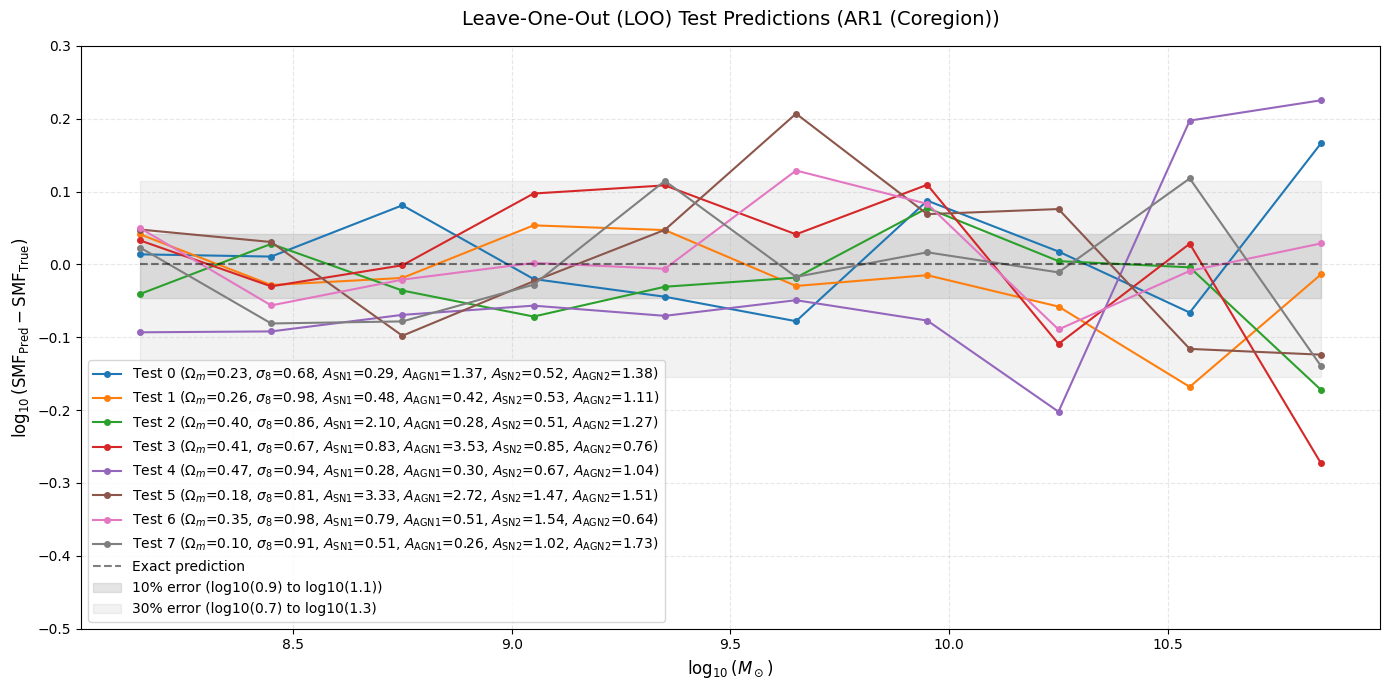

In [5]:
def plot_loo_predictions(log10_mass_bins, all_pred_exacts, smf_loader, num_hf):
    """
    Improved plot for LOO predictions, including parameter names and values for each test case.

    Args:
        log10_mass_bins: Bin centers for the stellar mass function in log10 scale.
        all_pred_exacts: Array of LOO predictions for each high-fidelity test case (num_loo x bins).
        smf_loader: SMFDataLoader instance containing test parameter values.
        num_hf: Number of high-fidelity datasets (number of LOO test cases).
    """
    # Extract parameter values for test cases
    param_names = [
        r"$\Omega_m$",
        r"$\sigma_8$",
        r"$A_\mathrm{SN1}$",
        r"$A_\mathrm{AGN1}$",
        r"$A_\mathrm{SN2}$",
        r"$A_\mathrm{AGN2}$",
    ]
    test_params = data.X_train[1][:num_hf]  # Test parameter values (num_hf x n_params)

    # Set up the figure
    plt.figure(figsize=(14, 7))

    # Plot each LOO case
    cmap = plt.get_cmap("tab10")  # Colormap for distinct colors
    for i in range(num_hf):
        label = f"Test {i} ({', '.join([f'{name}={value:.2f}' for name, value in zip(param_names, test_params[i])])})"
        plt.plot(
            log10_mass_bins,
            all_pred_exacts[i] - data.Y_train_log10[1][i],
            label=label,
            color=cmap(i % 10),
            marker="o",
            markersize=4,
            lw=1.5,
        )

    # Exact prediction line
    plt.plot(
        log10_mass_bins,
        np.log10(np.ones_like(log10_mass_bins)),
        label="Exact prediction",
        ls="--",
        color="k",
        alpha=0.5,
    )

    # Error bands
    plt.fill_between(
        log10_mass_bins,
        np.log10(0.9),
        np.log10(1.1),
        color="gray",
        alpha=0.2,
        label="10% error (log10(0.9) to log10(1.1))",
    )
    plt.fill_between(
        log10_mass_bins,
        np.log10(0.7),
        np.log10(1.3),
        color="gray",
        alpha=0.1,
        label="30% error (log10(0.7) to log10(1.3)",
    )

    # Customize plot
    plt.xlabel(r"$\log_{10} (M_\odot)$", fontsize=12)
    plt.ylabel(
        r"$\log_{10} (\mathrm{SMF}_{\mathrm{Pred}} - \mathrm{SMF}_{\mathrm{True}})$",
        fontsize=12,
    )
    plt.title("Leave-One-Out (LOO) Test Predictions", fontsize=14, pad=15)
    plt.ylim(-0.5, 0.3)
    plt.legend(loc="lower left", prop={"size": 10}, frameon=True)
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    # Show the plot
    # plt.show()


# Example Usage
# Assuming log10_mass_bins, all_pred_exacts, smf_loader, and num_hf are defined
num_hf = 8
plot_loo_predictions(log10_mass_bins, ar1_pred_means, data, num_hf)
plt.title("Leave-One-Out (LOO) Test Predictions (AR1 (Coregion))", fontsize=14, pad=15)

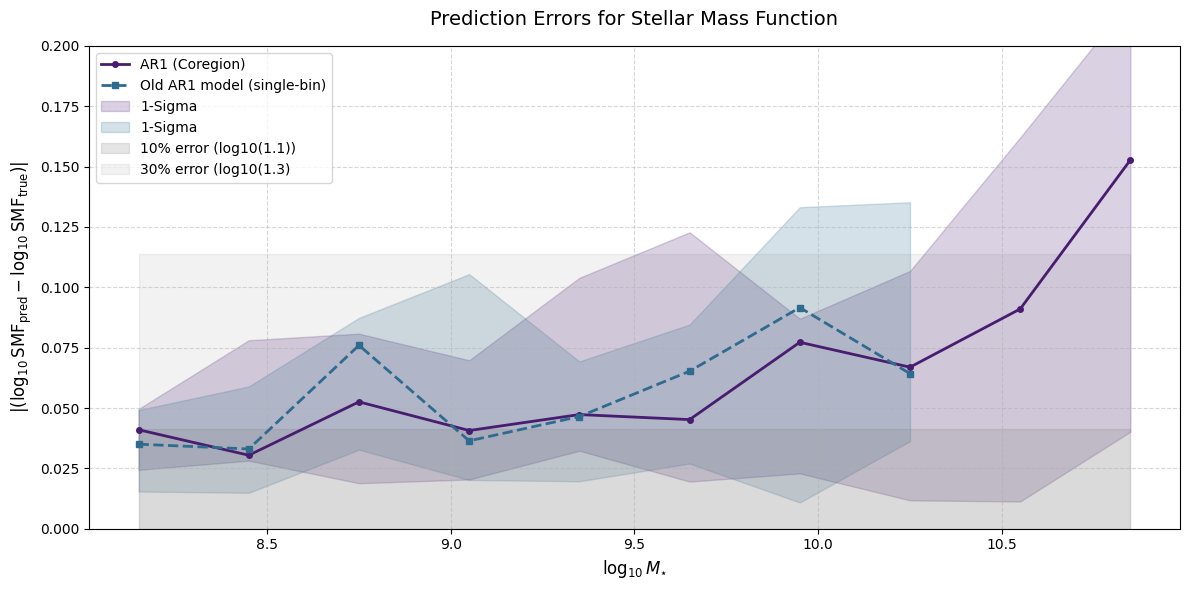

In [6]:
import matplotlib.pyplot as plt


def plot_prediction_errors(log10_mass_bins, all_pred_exacts, log_all_pred_exacts):
    """
    Plots the median and interquartile range of prediction errors with improved aesthetics.

    Args:
        log10_mass_bins: Bin centers for the stellar mass function in log10 scale.
        all_pred_exacts: Array of predictions for the log1p scale (multi-bin).
        log_all_pred_exacts: Array of predictions for the log scale (single-bin).
    """
    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(12, 6))

    # Compute metrics
    median_log1p = np.median(np.abs(all_pred_exacts - np.log10(1)), axis=0)
    q25_log1p = np.quantile(np.abs(all_pred_exacts - np.log10(1)), q=0.16, axis=0)
    q75_log1p = np.quantile(np.abs(all_pred_exacts - np.log10(1)), q=0.84, axis=0)

    median_log = np.median(np.abs(log_all_pred_exacts - np.log10(1)), axis=0)
    q25_log = np.quantile(np.abs(log_all_pred_exacts - np.log10(1)), q=0.16, axis=0)
    q75_log = np.quantile(np.abs(log_all_pred_exacts - np.log10(1)), q=0.84, axis=0)

    # Color palette
    color_log1p = "C0"
    color_log = "C1"

    # Plot the medians
    ax.plot(
        log10_mass_bins,
        median_log1p,
        color=color_log1p,
        lw=2,
        label="AR1 (Coregion)",
        linestyle="-",
        marker="o",
        markersize=4,
    )
    ax.plot(
        log10_mass_bins,
        median_log,
        color=color_log,
        lw=2,
        label="Old AR1 model (single-bin)",
        linestyle="--",
        marker="s",
        markersize=4,
    )

    # Fill interquartile ranges
    ax.fill_between(
        log10_mass_bins,
        q25_log1p,
        q75_log1p,
        color=color_log1p,
        alpha=0.2,
        label=r"1-Sigma",
    )
    ax.fill_between(
        log10_mass_bins,
        q25_log,
        q75_log,
        color=color_log,
        alpha=0.2,
        label=r"1-Sigma",
    )

    # Axes labels and titles
    ax.set_xlabel(r"$\log_{10} M_{\star}$", fontsize=12)
    ax.set_ylabel(
        r"$|(\log_{10} \mathrm{SMF}_{\mathrm{pred}} - \log_{10} \mathrm{SMF}_{\mathrm{true}}) |$",
        fontsize=12,
    )
    ax.set_title("Prediction Errors for Stellar Mass Function", fontsize=14, pad=15)

    # Add grid for better readability
    ax.grid(True, linestyle="--", alpha=0.5)

    # shaded areas for 10% and 30% error
    ax.fill_between(
        log10_mass_bins,
        np.log10(1),
        np.log10(1.1),
        color="gray",
        alpha=0.2,
        label="10% error (log10(1.1))",
    )
    ax.fill_between(
        log10_mass_bins,
        np.log10(1),
        np.log10(1.3),
        color="gray",
        alpha=0.1,
        label="30% error (log10(1.3)",
    )
    # Improve legend
    ax.legend(fontsize=10, loc="upper left", frameon=True)
    ax.set_ylim(0, 0.2)

    # Set tight layout for spacing
    plt.tight_layout()
    plt.show()

#### Previous result ####
# Loading from trained emulator results
num_loo = 8
load_fn = lambda i: "/Users/jibanmac/Documents/GitHub/camels_resolution/output_log/1004_LR_7_HR_test{}/AR1/".format(i)

log_all_pred_exacts = []

for i in range(num_loo):
    this_all_true = np.loadtxt(os.path.join(load_fn(i), "all_true"))
    this_all_gp_mean = np.loadtxt(os.path.join(load_fn(i), "all_gp_mean"))

    # log_all_pred_exacts.append(np.exp(this_all_gp_mean) / np.exp(this_all_true))

    # Make the pred/exact in log-scale
    this_pred_exact = np.log10(np.exp(this_all_gp_mean)) - np.log10(
        np.exp(this_all_true)
    )
    log_all_pred_exacts.append(this_pred_exact)

log_all_pred_exacts = np.array(log_all_pred_exacts)

# Example Usage
plot_prediction_errors(log10_mass_bins, ar1_pred_means - data.Y_train_log10[1], log_all_pred_exacts)